In [5]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, RocCurveDisplay
)
from imblearn.over_sampling import SMOTE

In [6]:
df = pd.read_csv("../../results/outputs/final_preprocessed_telco_data_new.csv")

In [7]:
display(df.head())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Churn
0,-2.839944,-1.247643,1.014425,-0.339953,-1.099294,0.092576,0.517341,0.408477,-0.086671,-0.036771,0
1,-0.352317,1.434602,-0.451466,-0.359328,0.000225,-0.189705,-0.298579,-0.370672,-0.114527,0.056526,0
2,-2.088348,-0.190338,-1.506188,-1.079722,-0.208352,-0.238015,0.160883,-0.210342,0.153532,0.008629,1
3,-0.375654,1.872523,-0.302458,-0.423412,-0.256734,-0.361657,-0.244218,0.374798,0.185815,0.003063,0
4,-1.362409,-2.841712,0.577507,0.012427,0.531640,0.700028,0.178311,-0.106544,0.143042,-0.114418,1


In [8]:
# Define features & target
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [9]:
# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

In [10]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

In [11]:
# Function to Train & Evaluate Each Variety
def evaluate_decision_tree(criterion_name):
    print(f"Decision Tree ({criterion_name.upper()})")


    param_grid = {
        'max_depth': [3, 5, 7, 9, 12, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

    dt = DecisionTreeClassifier(criterion=criterion_name, random_state=42, class_weight='balanced')
    grid = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("✅ Best Parameters:", grid.best_params_)
    print(f"✅ Accuracy: {acc:.4f}")
    print(f"✅ Precision: {prec:.4f}")
    print(f"✅ Recall: {rec:.4f}")
    print(f"✅ F1 Score: {f1:.4f}")
    print("\n Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f"Confusion Matrix - Decision Tree ({criterion_name.capitalize()})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    RocCurveDisplay.from_estimator(best_model, X_test, y_test)
    plt.title(f"ROC Curve - Decision Tree ({criterion_name.capitalize()})")
    plt.show()

    return {
        "Criterion": criterion_name.capitalize(),
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "Best Params": grid.best_params_
    }

Decision Tree (GINI)
✅ Best Parameters: {'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 2}
✅ Accuracy: 0.7812
✅ Precision: 0.7517
✅ Recall: 0.8396
✅ F1 Score: 0.7932

 Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.72      0.77      1035
           1       0.75      0.84      0.79      1035

    accuracy                           0.78      2070
   macro avg       0.79      0.78      0.78      2070
weighted avg       0.79      0.78      0.78      2070



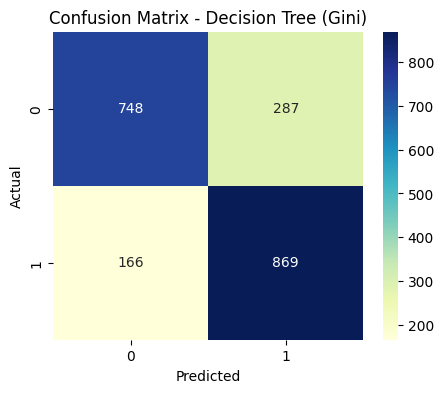

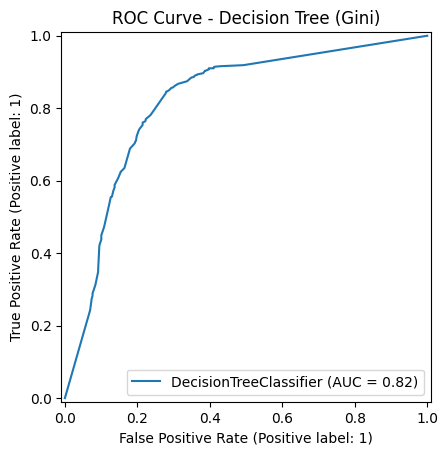

Decision Tree (ENTROPY)
✅ Best Parameters: {'max_depth': 9, 'min_samples_leaf': 2, 'min_samples_split': 5}
✅ Accuracy: 0.7710
✅ Precision: 0.7552
✅ Recall: 0.8019
✅ F1 Score: 0.7779

 Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.74      0.76      1035
           1       0.76      0.80      0.78      1035

    accuracy                           0.77      2070
   macro avg       0.77      0.77      0.77      2070
weighted avg       0.77      0.77      0.77      2070



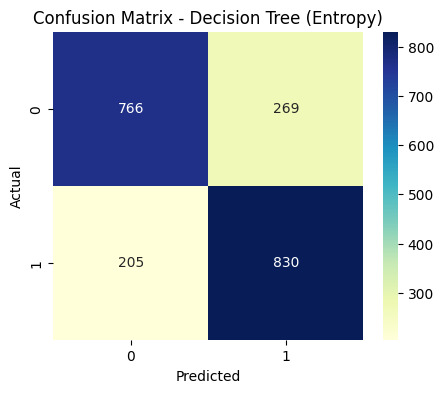

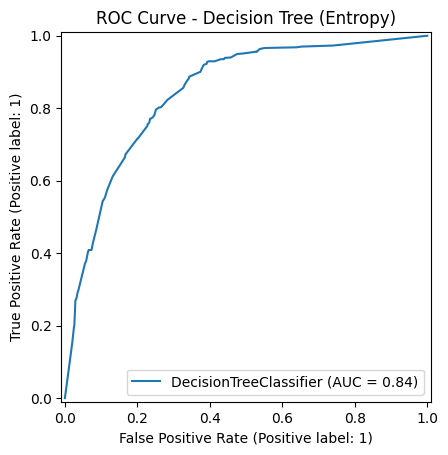

Decision Tree (LOG_LOSS)
✅ Best Parameters: {'max_depth': 9, 'min_samples_leaf': 2, 'min_samples_split': 5}
✅ Accuracy: 0.7710
✅ Precision: 0.7552
✅ Recall: 0.8019
✅ F1 Score: 0.7779

 Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.74      0.76      1035
           1       0.76      0.80      0.78      1035

    accuracy                           0.77      2070
   macro avg       0.77      0.77      0.77      2070
weighted avg       0.77      0.77      0.77      2070



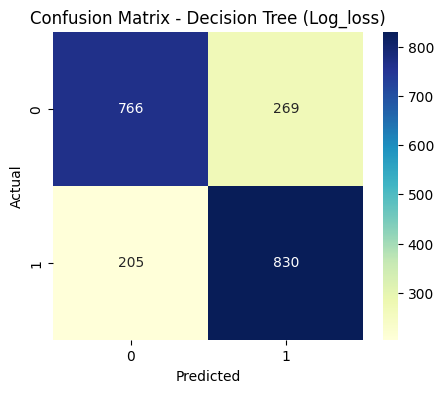

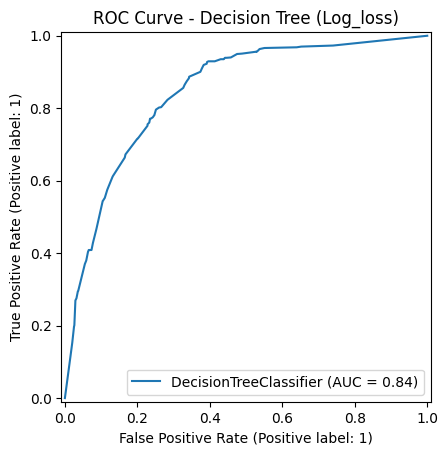

In [12]:
#results for each varieties
results = []
for criterion in ['gini', 'entropy', 'log_loss']:
    result = evaluate_decision_tree(criterion)
    results.append(result)


In [13]:
# comparison table
comparison_df = pd.DataFrame(results)
print("Comparison of Decision Tree Varieties ")
display(comparison_df.style.background_gradient(cmap="Blues").format({
    "Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}", "F1 Score": "{:.4f}"
}))

Comparison of Decision Tree Varieties 


,Criterion,Accuracy,Precision,Recall,F1 Score,Best Params
0,Gini,0.7812,0.7517,0.8396,0.7932,"{'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 2}"
1,Entropy,0.7710,0.7552,0.8019,0.7779,"{'max_depth': 9, 'min_samples_leaf': 2, 'min_samples_split': 5}"
2,Log_loss,0.7710,0.7552,0.8019,0.7779,"{'max_depth': 9, 'min_samples_leaf': 2, 'min_samples_split': 5}"


C:\Users\USER\AppData\Local\Temp\ipykernel_13356\1649284825.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Criterion', y='Accuracy', data=comparison_df, palette='Blues_d')


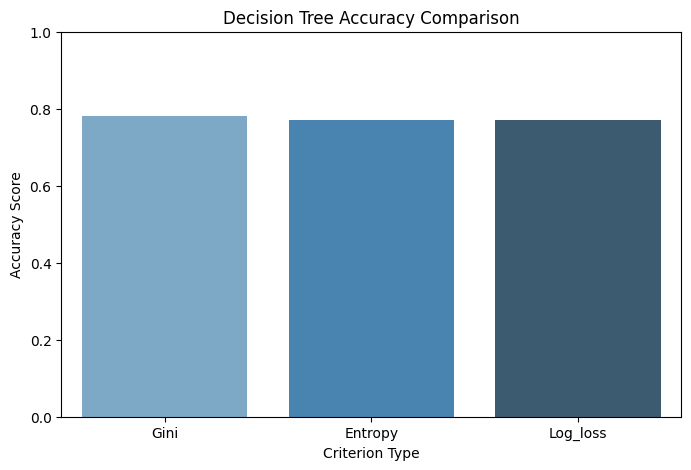

In [14]:
# Visual Comparison

plt.figure(figsize=(8, 5))
sns.barplot(x='Criterion', y='Accuracy', data=comparison_df, palette='Blues_d')
plt.title("Decision Tree Accuracy Comparison")
plt.ylabel("Accuracy Score")
plt.xlabel("Criterion Type")
plt.ylim(0, 1)
plt.show()

In [15]:
# Highlight best model
best_model_name = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Criterion']
print(f"\n Best Performing Model: Decision Tree ({best_model_name})")


 Best Performing Model: Decision Tree (Gini)
